ID_CLIENTE                           0
QUANT_CONTAS_BANCARIAS               0
QUANT_CONTAS_BANCARIAS_ESPECIAIS     0
VALOR_PATRIMONIO_PESSOAL             0
QUANT_CARROS                         0
EMPRESA                              0
ESTADO_PROFISSIONAL                  0
CIDADE_PROFISSIONAL                  0
BAIRRO_PROFISSIONAL                  0
FLAG_TELEFONE_PROFISSIONAL           0
CODIGO_AREA_TELEFONE_PROFISSIONAL    0
MESES_NO_TRABALHO                    0
CODIGO_PROFISSAO                     0
TIPO_OCUPACAO                        0
CODIGO_PROFISSAO_CONJUGE             0
NIVEL_EDUCACIONAL_CONJUGE            0
FLAG_DOCUMENTO_RESIDENCIAL           0
FLAG_RG                              0
FLAG_CPF                             0
FLAG_COMPROVANTE_RENDA               0
PRODUTO                              0
FLAG_REGISTRO_ACSP                   0
IDADE                                0
CEP_RESIDENCIAL                      0
FLAG_OUTROS_CARTOES                  0
FLAG_AMERICAN_EXPRESS    

/var/folders/xz/khfgvmxj4tsd1nl_m4gdk7780000gn/T/ipykernel_7008/2732135665.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)


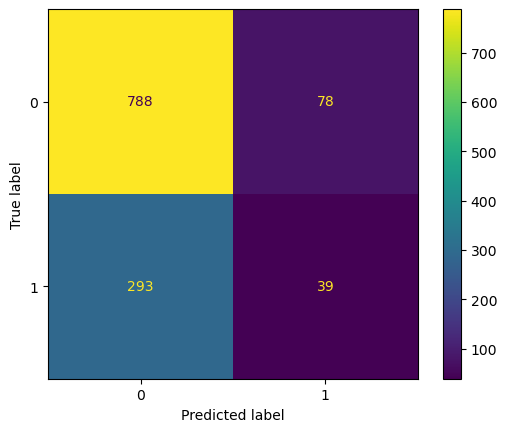

In [25]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix

# URL do arquivo
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Especificando a codificação para ler o arquivo CSV
dados_credito = pd.read_csv(url, encoding='ISO-8859-1', sep='\t', low_memory=False)
# or 'ISO-8859-1' if 'latin-1' doesn't work
nomes_cols = ['ID_CLIENTE','TIPO_FUNCIONARIO','DIA_PAGAMENTO','TIPO_ENVIO_APLICACAO','QUANT_CARTOES_ADICIONAIS','TIPO_ENDERECO_POSTAL','SEXO','ESTADO_CIVIL','QUANT_DEPENDENTES',
'NIVEL_EDUCACIONAL','ESTADO_NASCIMENTO','CIDADE_NASCIMENTO','NACIONALIDADE','ESTADO_RESIDENCIAL','CIDADE_RESIDENCIAL','BAIRRO_RESIDENCIAL','FLAG_TELEFONE_RESIDENCIAL',
'CODIGO_AREA_TELEFONE_RESIDENCIAL','TIPO_RESIDENCIA','MESES_RESIDENCIA','FLAG_TELEFONE_MOVEL','FLAG_EMAIL','RENDA_PESSOAL_MENSAL','OUTRAS_RENDAS',
'FLAG_VISA','FLAG_MASTERCARD','FLAG_DINERS','FLAG_AMERICAN_EXPRESS','FLAG_OUTROS_CARTOES','QUANT_CONTAS_BANCARIAS','QUANT_CONTAS_BANCARIAS_ESPECIAIS',
'VALOR_PATRIMONIO_PESSOAL','QUANT_CARROS','EMPRESA','ESTADO_PROFISSIONAL','CIDADE_PROFISSIONAL','BAIRRO_PROFISSIONAL','FLAG_TELEFONE_PROFISSIONAL',
'CODIGO_AREA_TELEFONE_PROFISSIONAL','MESES_NO_TRABALHO','CODIGO_PROFISSAO','TIPO_OCUPACAO','CODIGO_PROFISSAO_CONJUGE','NIVEL_EDUCACIONAL_CONJUGE',
'FLAG_DOCUMENTO_RESIDENCIAL','FLAG_RG','FLAG_CPF','FLAG_COMPROVANTE_RENDA','PRODUTO','FLAG_REGISTRO_ACSP','IDADE','CEP_RESIDENCIAL','CEP_PROFISSIONAL','ROTULO_ALVO_MAU']

dados_credito.columns = nomes_cols

dados_credito.describe()
dados_credito.isnull().sum().sort_values(ascending=True)



# Removendo linhas com valores nulos
dados_credito_limpo = dados_credito.dropna()

# Exibindo a quantidade de valores nulos após a remoção
print(dados_credito_limpo.isnull().sum().sort_values(ascending=True))

dados_credito_limpo.head()

valores_unicos_sexo = dados_credito_limpo['SEXO'].unique()
valores_unicos_sexo


dados_credito_limpo.loc[dados_credito_limpo["SEXO"].replace(' ', np.nan).isna(), "SEXO"] = 'N'
dados_credito_limpo.head()

# Verificando valores disponíveis pra sexo
dados_credito_limpo['SEXO'].unique()


mapping = {'M': 0, 'F': 1, 'N': 2}
dados_credito_limpo['SEXO'] = dados_credito_limpo['SEXO'].map(mapping)

dados_credito_limpo['SEXO'].unique()
y = dados_credito_limpo["ROTULO_ALVO_MAU"]

# Drop the specified columns
columns_to_drop = ['TIPO_FUNCIONARIO', 'TIPO_ENVIO_APLICACAO', 'ESTADO_NASCIMENTO', 'CIDADE_NASCIMENTO',
                  'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL', 'FLAG_TELEFONE_RESIDENCIAL',
                  'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'FLAG_TELEFONE_MOVEL', 'EMPRESA', 'ESTADO_PROFISSIONAL',
                  'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
                  'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'FLAG_REGISTRO_ACSP', 'CEP_RESIDENCIAL', 'CEP_PROFISSIONAL']
X = dados_credito_limpo.drop(columns=columns_to_drop + ["ROTULO_ALVO_MAU"])


#
## train test split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=50)

model_filter=XGBClassifier()
model_filter.fit(X_train,y_train)

y_pred=model_filter.predict(X_test)

metric_filter=confusion_matrix(y_test,y_pred)

print (classification_report(y_test, y_pred))

cm = confusion_matrix( y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()


In [26]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       866
           1       0.33      0.12      0.17       332

    accuracy                           0.69      1198
   macro avg       0.53      0.51      0.49      1198
weighted avg       0.62      0.69      0.63      1198

